In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np
import shap
import lime
import lime.lime_tabular

In [ ]:
#                           Data Collection
data = pd.read_csv('data_rf.csv')
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values(by='Date', ascending=True)
data = data.set_index('Date')
data.dropna(inplace=True)

# Initialisation of variables
X = data.drop('US T-Note 10Y Yield', axis=1) # Dataset, the target data is removed from it
Y = data['US T-Note 10Y Yield'] # Target data to predict is 10Y U.S. T-Note

print('\t Data Head :', '\n', data.head(), '\n')
print('Data Shape :', data.shape)

	 Data Head : 
             US T-Note 10Y Yield  USD/EUR  US Unemployment     US GDP  XAU/USD  \
Date                                                                            
1990-07-01                8.351    0.756              9.6  10090.569   370.75   
1990-08-01                8.859    0.751              9.4  10090.569   383.00   
1990-09-01                8.810    0.747              9.3  10090.569   403.15   
1990-10-01                8.627    0.724              9.0   9998.704   380.20   
1990-11-01                8.256    0.720              8.9   9998.704   382.25   

            USD Index  OIL WTI    VIX  Interest Rates  US T-Bond 30Y Yield  \
Date                                                                         
1990-07-01      87.43    20.69  21.11            8.15                94.69   
1990-08-01      86.85    27.32  29.90            8.13                89.16   
1990-09-01      86.52    39.51  29.11            8.20                89.38   
1990-10-01      83.56    3

In [7]:
#                            Train, Test Split
split_point = int(len(X) * 0.75) # 75% Train, 25% Test
X_train, X_test = X[:split_point], X[split_point:]
Y_train, Y_test = Y[:split_point], Y[split_point:]

n, p = X_test.shape[0], X_test.shape[1] # NB of samples and features in test set (Useful for R2 Adjusted)

In [15]:
#                           Random Forest Training
# Hyperparameters & Model Prediction
rf_model = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=1, max_features='sqrt', min_samples_split=10,
                                 bootstrap=True, max_samples=None, max_leaf_nodes=None, n_jobs=-1, oob_score=True)
rf_model.fit(X_train, Y_train)
rf_Y_pred = rf_model.predict(X_test)

# Metrics
RF_MSE = mean_squared_error(Y_test, rf_Y_pred)
RF_R2 = r2_score(Y_test, rf_Y_pred)
RF_R2_ADJ = 1 - (((1 - RF_R2) * (n - 1)) / (n - p - 1))
OOB_SCORE = rf_model.oob_score_ # Out-Of-Bag score estimates the model's generalization performance
rf_feature_importance = pd.Series(rf_model.feature_importances_, index=list(X.columns)).sort_values(ascending=False) # Table that show % of contribution of each data

print('\tRandom Forest Prediction Metrics :', '\n', f'\nOut-of-Bag Score: {round(OOB_SCORE, 3)}', f'\nMSE = {round(RF_MSE,3)} \nR2 = {round(RF_R2,3)} \nAdjusted R2 = {round(RF_R2_ADJ,3)}\n'); print('\nFeature Importance :\n', f'\n{rf_feature_importance}')


	Random Forest Prediction Metrics : 
 
Out-of-Bag Score: 0.989 
MSE = 0.296 
R2 = 0.769 
Adjusted R2 = 0.741


Feature Importance :
 
US GDP                 0.257659
US T-Note 5Y Yield     0.158905
Interest Rates         0.144606
US T-Note 2Y Yield     0.129151
XAU/USD                0.092062
US T-Bond 30Y Yield    0.085724
OIL WTI                0.066452
US Unemployment        0.035995
USD/EUR                0.014450
USD Index              0.010878
VIX                    0.004120
dtype: float64


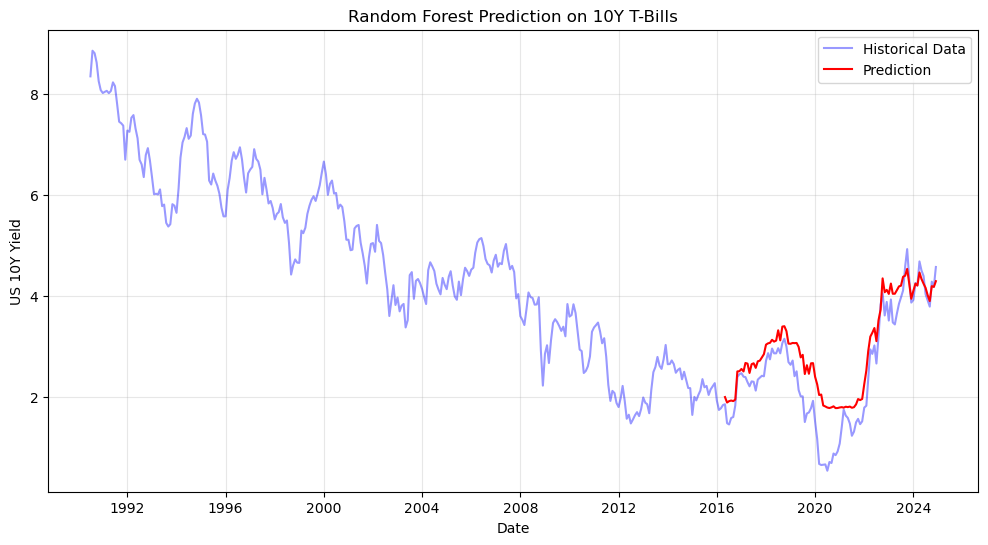

In [16]:
# Plot the Prediction
plt.figure(figsize=(12,6))
plt.plot(data.index, data['US T-Note 10Y Yield'], label='Historical Data', color='blue', alpha=0.4)
plt.plot(Y_test.index, rf_Y_pred, label='Prediction', color='red', alpha=1)
plt.title('Random Forest Prediction on 10Y T-Bills'); plt.xlabel('Date'); plt.ylabel('US 10Y Yield'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

	 SHAP :


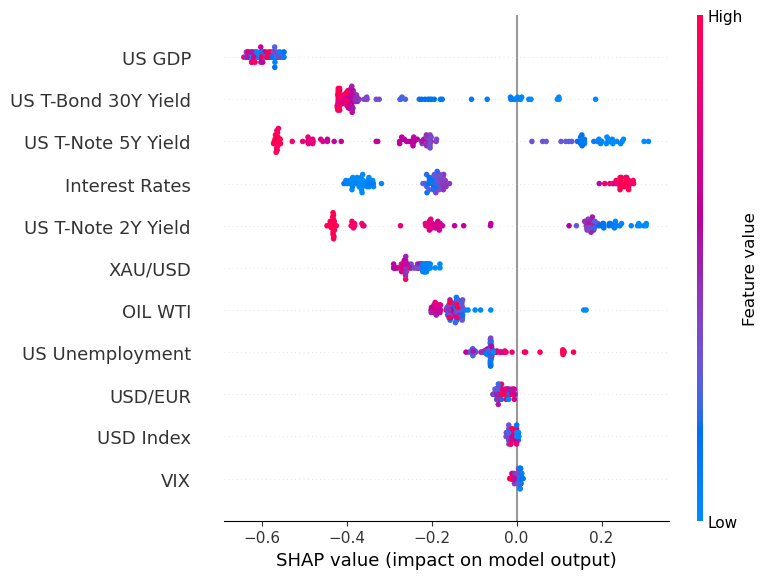

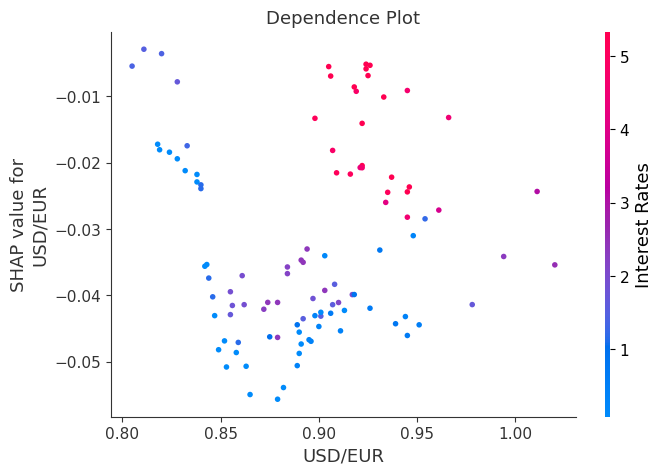

In [23]:
#                           SHAP
print('\t SHAP :')

# Plots features contribution
rf_explainer_shap = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer_shap(X_test)
shap.summary_plot(rf_shap_values.values, X_test, feature_names=X.columns, title='Summary Plot')

# Shows impact of a single feature on model prediction
feature_number = 0 # Choose the feature, ranges 0 to 10
shap.dependence_plot(feature_number, rf_shap_values.values, X_test, feature_names=X.columns, title='Dependence Plot')

In [39]:
#                           LIME
rf_explainer_lime = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names=X_train.columns, verbose=True, mode='regression')
i = np.random.randint(0, X_test.shape[0])
exp = rf_explainer_lime.explain_instance(X_test.values[i], rf_model.predict, num_features=len(X_test.columns))
exp.show_in_notebook(show_all=True)

Intercept 4.845010860902588
Prediction_local [4.23524813]
Right: 4.191862543442124


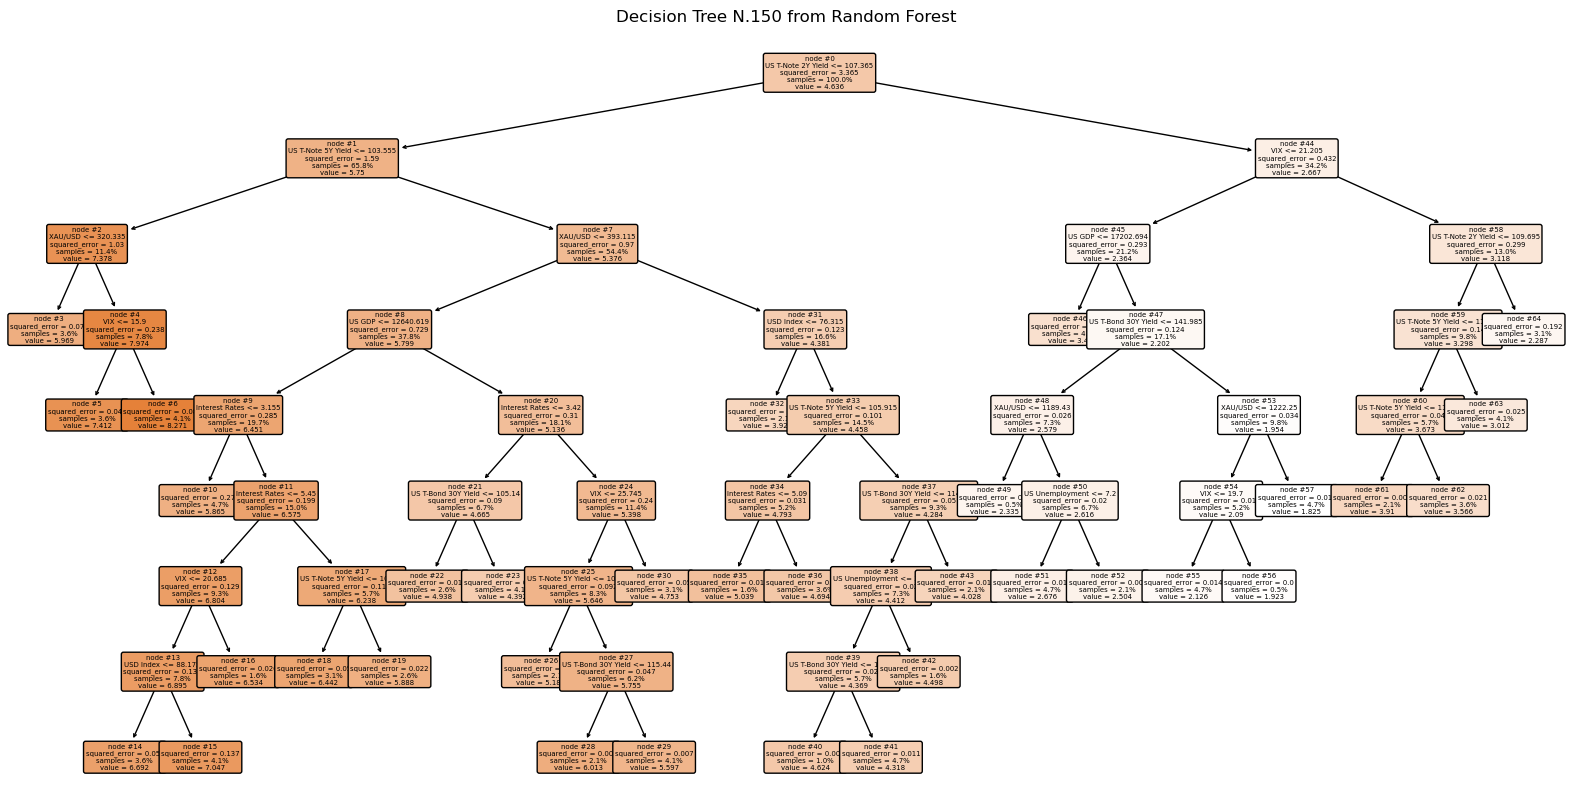

In [40]:
# Plot a tree used in the Random Forest Regression
tree_position = 150 # Number specifies the tree position, goes up to 300
tree_to_plot = rf_model.estimators_[tree_position]

plt.figure(figsize=(20, 10))
plot_tree(decision_tree=tree_to_plot, feature_names=X_train.columns, filled=True, rounded=True, impurity=True, proportion=True, node_ids=True, fontsize=5)
plt.title(f'Decision Tree N.{tree_position} from Random Forest')
plt.show()